In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import torch

In [3]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
df = yf.download("RELIANCE.NS", start="2019-01-01", end="2024-01-01")


/tmp/ipykernel_55/1461500351.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("RELIANCE.NS", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2019-01-01,498.490540,501.292086,493.643505,500.380481,9746670
2019-01-02,491.998230,501.158723,489.596917,495.600156,15628818
2019-01-03,485.928314,495.644647,484.749906,492.487392,16288287
2019-01-04,488.551910,491.131092,480.747723,487.996071,18516544
2019-01-07,491.264465,497.356638,489.596889,492.265005,12060290


In [6]:
df.shape

(1235, 5)

In [7]:
df.isnull().sum()

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1235 entries, 2019-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1235 non-null   float64
 1   (High, RELIANCE.NS)    1235 non-null   float64
 2   (Low, RELIANCE.NS)     1235 non-null   float64
 3   (Open, RELIANCE.NS)    1235 non-null   float64
 4   (Volume, RELIANCE.NS)  1235 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 57.9 KB


In [9]:

df.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,1235.000000,1235.000000,1235.000000,1235.000000,1.235000e+03
mean,937.053485,947.671009,927.314735,937.868421,2.079654e+07
std,240.464648,241.565886,239.273717,240.461458,1.611350e+07
min,395.482483,424.985412,391.724705,409.864862,1.705656e+06
25%,687.235016,693.397320,681.095073,689.357542,1.131555e+07
50%,998.501038,1011.151722,987.369231,1001.026461,1.593215e+07
75%,1144.406067,1153.522257,1135.201173,1144.407531,2.395899e+07
max,1297.294922,1303.754399,1283.922210,1299.582584,1.426834e+08


In [10]:
data=df.values

In [11]:
split=int(len(data)*0.8)
train_data=data[:split]
test_data=data[split:]

In [12]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(train_data)
train_data=scaler.transform(train_data)
test_data=scaler.transform(test_data)


In [13]:
print(train_data.shape)
print(test_data.shape)


(988, 5)
(247, 5)


In [14]:
def create_sequences(data,seq_len):
  X,y=[],[]
  for i in range(seq_len,len(data)):
    X.append(data[i-seq_len:i])
    y.append([data[i,0]])  # Changed to append a list to make it 2D
  return np.array(X),np.array(y)

In [15]:
import torch
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, rnn_type="LSTM"):
        super().__init__()

        if rnn_type == "LSTM":
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers,
                               dropout=dropout, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers,
                              dropout=dropout, batch_first=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)


In [40]:
from sklearn.model_selection import TimeSeriesSplit
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [41]:
# #Hyper parametrer tuning with Cross val score

In [45]:
def objective(trial):
  batch_size=trial.suggest_int('batch_size',16,64, step=16)
  epochs=trial.suggest_int('epochs',50,200,step=50)
  lr=trial.suggest_float('lr', 1e-5,1e-3,log=True)
  weight_decay=trial.suggest_float('weight_decay',1e-5,1e-2, log=True)
  hidden_size=trial.suggest_int('hidden_size',32,128,step=32)
  num_layers=trial.suggest_int('num_layers',2,4,step=1)
  dropout=trial.suggest_float('dropout',0.1,0.5,step=0.1)
  seq_len=trial.suggest_int('seq_len',30,120,step=30)
  optimizer_name=trial.suggest_categorical('optimizer',['Adam','SGD'])
  rnn_type=trial.suggest_categorical('rnn_type',['LSTM','GRU'])

  scores=[]
  tscv=TimeSeriesSplit(n_splits=3)

  X_seq, y_seq=create_sequences(train_data, seq_len)
  X_seq_tensor=torch.FloatTensor(X_seq).to(device)
  y_seq_tensor=torch.FloatTensor(y_seq).to(device)

  for train_idx, val_idx in tscv.split(X_seq_tensor):
    X_train,X_val=X_seq_tensor[train_idx],X_seq_tensor[val_idx]
    y_train,y_val=y_seq_tensor[train_idx],y_seq_tensor[val_idx]

    train_loader=DataLoader(TensorDataset(X_train,y_train), batch_size=batch_size, shuffle=False, pin_memory=False)

    model=RNNModel(5,hidden_size,num_layers,dropout,rnn_type).to(device)
    if optimizer_name=='Adam':
      optimizer=optim.Adam(model.parameters(),lr=lr, weight_decay=weight_decay)
    else:
      optimizer=optim.SGD(model.parameters(),lr=lr,weight_decay=weight_decay)
    criterion=nn.MSELoss()

    for i in range(epochs):
      model.train()
      for xb,yb in train_loader:
        xb,yb=xb.to(device),yb.to(device)
        yhat=model(xb)
        loss=criterion(yhat,yb)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Added gradient clipping
        optimizer.step()

    model.eval()
    with torch.no_grad():
      val_pred=model(X_val).cpu().numpy()
      val_true=y_val.cpu().numpy()
      score=mean_squared_error(val_true,val_pred)
    scores.append(-score)
  return np.mean(scores)

In [44]:
pip install optuna


Note: you may need to restart the kernel to use updated packages.


In [46]:
import optuna
study=optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)
print("Best Params:", study.best_params)
print("Best CV score:", study.best_value)

[I 2026-04-28 09:35:00,764] A new study created in memory with name: no-name-cea46bfa-35ce-4e3c-89fc-08b98b4e3b2f
[I 2026-04-28 09:35:05,268] Trial 0 finished with value: -0.7152371307214102 and parameters: {'batch_size': 64, 'epochs': 50, 'lr': 0.0004429709737763398, 'weight_decay': 0.0032692627053414304, 'hidden_size': 96, 'num_layers': 4, 'dropout': 0.5, 'seq_len': 30, 'optimizer': 'SGD', 'rnn_type': 'GRU'}. Best is trial 0 with value: -0.7152371307214102.
[I 2026-04-28 09:35:41,921] Trial 1 finished with value: -0.05721587594598532 and parameters: {'batch_size': 16, 'epochs': 150, 'lr': 0.00015451950666117755, 'weight_decay': 2.869287456795773e-05, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2, 'seq_len': 120, 'optimizer': 'Adam', 'rnn_type': 'LSTM'}. Best is trial 1 with value: -0.05721587594598532.
[I 2026-04-28 09:35:46,131] Trial 2 finished with value: -0.033139736081163086 and parameters: {'batch_size': 64, 'epochs': 50, 'lr': 0.0008074673447379699, 'weight_decay': 0.004

Best Params: {'batch_size': 48, 'epochs': 150, 'lr': 0.0001706519344700931, 'weight_decay': 0.0007468538094672756, 'hidden_size': 96, 'num_layers': 2, 'dropout': 0.2, 'seq_len': 60, 'optimizer': 'Adam', 'rnn_type': 'GRU'}
Best CV score: -0.01654789038002491


In [21]:
import random
import os
import numpy as np
import torch

def fix_reproducibility(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_reproducibility(42)

In [50]:
# best = study.best_params
seq_len =60

X_train_seq, y_train_seq = create_sequences(train_data, seq_len)

test_with_context = np.vstack([train_data[-seq_len:], test_data])
X_test_seq, y_test_seq = create_sequences(test_with_context, seq_len)

X_train_seq = torch.tensor(X_train_seq, dtype=torch.float32).to(device)
y_train_seq = torch.tensor(y_train_seq, dtype=torch.float32).to(device)
X_test_seq = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
y_test_seq = torch.tensor(y_test_seq, dtype=torch.float32).to(device)

seeds = [1, 7, 21, 42, 100]
train_scores, test_scores = [], []

for seed in seeds:
    fix_reproducibility(seed)

    final_model = RNNModel(
        input_size=X_train_seq.shape[2],
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
        rnn_type='GRU'
    ).to(device)

    optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_losses = []

    for epoch in range(160):
        final_model.train()

        pred = final_model(X_train_seq).squeeze()
        loss = criterion(pred, y_train_seq.squeeze())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    final_model.eval()
    with torch.no_grad():
        train_pred = final_model(X_train_seq).squeeze().cpu().numpy()
        train_true = y_train_seq.squeeze().cpu().numpy()

        test_pred = final_model(X_test_seq).squeeze().cpu().numpy()
        test_true = y_test_seq.squeeze().cpu().numpy()

    train_scores.append(r2_score(train_true, train_pred))
    test_scores.append(r2_score(test_true, test_pred))

print("Train R2 scores:", train_scores)
print("Test R2 scores :", test_scores)

print(f"Mean Train R2: {np.mean(train_scores)*100:.2f}%")
print(f"Std Train R2 : {np.std(train_scores)*100:.2f}%")

print(f"Mean Test R2 : {np.mean(test_scores)*100:.2f}%")
print(f"Std Test R2  : {np.std(test_scores)*100:.2f}%")

Train R2 scores: [0.9893810749053955, 0.9878627061843872, 0.9888820052146912, 0.9884404540061951, 0.9890567660331726]
Test R2 scores : [0.9081436395645142, 0.8922379016876221, 0.908043622970581, 0.9011167883872986, 0.9077023863792419]
Mean Train R2: 98.87%
Std Train R2 : 0.05%
Mean Test R2 : 90.34%
Std Test R2  : 0.62%


In [51]:
# Inverse transform to get actual prices
close_scaler = StandardScaler()
close_scaler.fit(df[['Close']].iloc[:split])
preds_actual = close_scaler.inverse_transform(test_pred.reshape(-1,1))
y_actual = close_scaler.inverse_transform(y_test_seq.cpu().numpy().reshape(-1,1))

# RMSE
rmse = np.sqrt(np.mean((preds_actual - y_actual)**2))
print(f"RMSE: {rmse:.2f}")

RMSE: 20.75


In [53]:
len(y_actual)

247

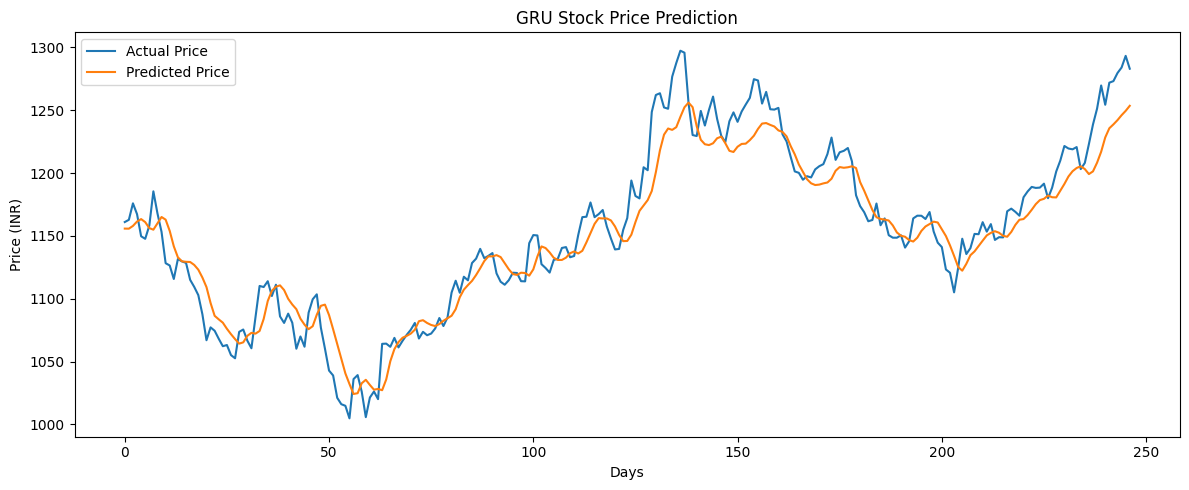

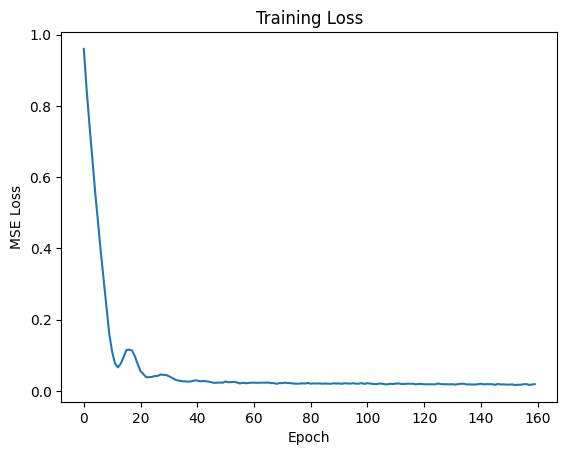

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_actual, label='Actual Price', linewidth=1.5)
plt.plot(preds_actual, label='Predicted Price', linewidth=1.5)
plt.title('GRU Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('lstm_prediction.png', dpi=150)
plt.show()

# Loss curve
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.savefig('loss_curve.png')
plt.show()